# **Maximum Likelihood Estimation to approximate Gaussian distribution**

An approximation of the Gaussian distribution can be obtained using Maximum Likelihood Estimation (MLE). MLE aims to find the parameters of the distribution (mean and variance) that maximize the likelihood of the observed data. 

In this case, we want to approximate the value of mu (mean) and sigma (standard deviation) of the Gaussian distribution using MLE.

The likelihood function for a Gaussian distribution with parameters mu and sigma given data points x_1, x_2, ..., x_n is:
$$
L(\mu, \sigma) = \prod_{i=1}^{n} \frac{1}{\sqrt{2 \pi \sigma^2}} \exp \left( -\frac{(x_i - \mu)^2}{2 \sigma^2} \right)
$$  
To simplify the optimization, we often work with the log-likelihood function, which is the natural logarithm of the likelihood function:
$$
|\ell(\mu, \sigma) = \log L(\mu, \sigma) = \sum_{i=1}^{n} \log \left( \frac{1}{\sqrt{2 \pi \sigma^2}} \exp \left( -\frac{(x_i - \mu)^2}{2 \sigma^2} \right) \right)
$$
This can be further simplified to:
$$
\ell(\mu, \sigma) = -\frac{n}{2} \log (2 \pi \sigma^2) - \frac{1}{2 \sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2
$$
To find the MLE estimates of mu and sigma, we take the partial derivatives of the log-likelihood function with respect to mu and sigma, set them to zero, and solve for the parameters. The resulting MLE estimates are:
$$
\hat{\mu} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$
$$
\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{\mu})^2
$$
These formulas provide the maximum likelihood estimates for the mean and variance of a Gaussian distribution based on the observed data. The estimate for the mean is simply the sample average, and the estimate for the variance is the average of the squared deviations from the sample mean.

In [1]:
# Import libraries
from sklearn.datasets import make_blobs
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

In [2]:
X1, Y1 = make_blobs(n_features=2, centers=3, random_state=43, cluster_std=0.5)
Y1=Y1.reshape(-1,1)
# print("X1", X1[::10])
# print("Y1", Y1[::10])
X=np.hstack((X1,Y1))
X[::10]

array([[-3.5822916 ,  6.92833462,  2.        ],
       [-2.44946968,  6.66702575,  2.        ],
       [-7.55065779, -4.67863944,  1.        ],
       [-7.67716662, -5.28738495,  1.        ],
       [-7.24156325, -5.6007935 ,  1.        ],
       [-2.95076764,  7.20427269,  2.        ],
       [-8.03841223,  2.94582335,  0.        ],
       [-3.35457229,  6.57092995,  2.        ],
       [-7.23034302, -6.11646795,  1.        ],
       [-8.53324003,  1.75028804,  0.        ]])

In [3]:
X[X[:,2]==1].std(axis=0)

array([0.55690036, 0.40306695, 0.        ])

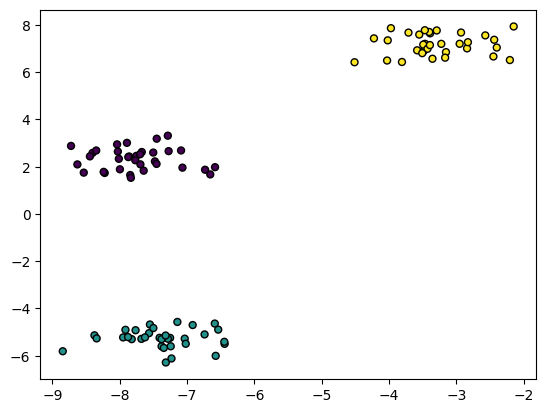

In [4]:
plt.scatter(X1[:, 0], X1[:, 1], marker="o", c=Y1, s=25, edgecolor="k")
plt.show()

In [5]:
X1.shape
Y1.shape
X.shape

(100, 3)

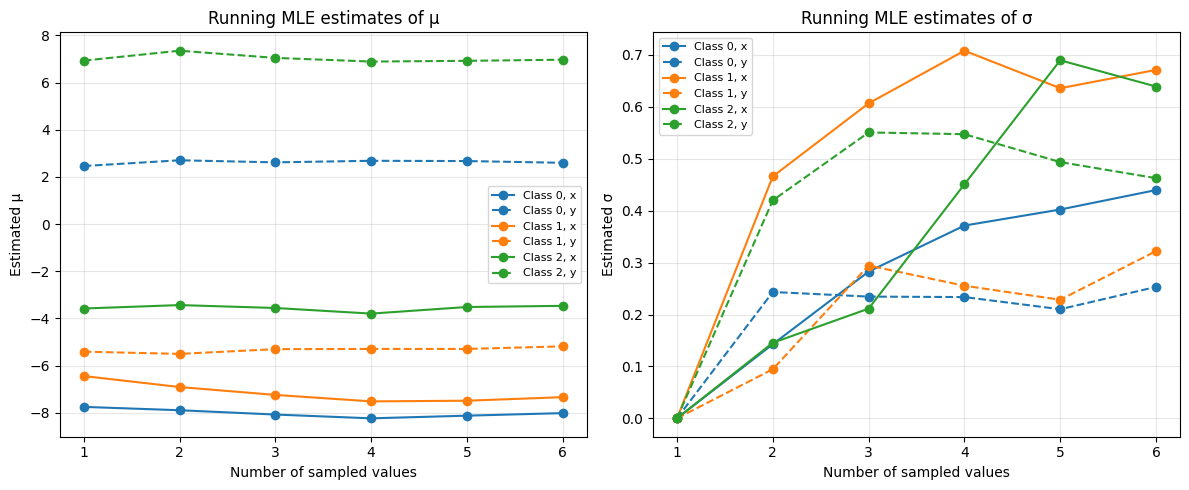

In [6]:
rng = np.random.default_rng(0)
n_per_class = 6
sample_sizes = np.arange(1, n_per_class + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for label in np.unique(Y1):
    points = X1[Y1.ravel() == label]
    sample = points[rng.choice(len(points), size=n_per_class, replace=False)]
    color = plt.cm.tab10(int(label))

    for feature, name, linestyle in [
        (0, "x", "-"),
        (1, "y", "--")
    ]:
        values = sample[:, feature]

        # MLE estimates using the first k observations, for k = 1,...,6
        mu_estimates = [values[:k].mean() for k in sample_sizes]
        sigma_estimates = [values[:k].std(ddof=0) for k in sample_sizes]

        axes[0].plot(
            sample_sizes, mu_estimates, marker="o", color=color,
            linestyle=linestyle, label=f"Class {label}, {name}"
        )
        axes[1].plot(
            sample_sizes, sigma_estimates, marker="o", color=color,
            linestyle=linestyle, label=f"Class {label}, {name}"
        )

axes[0].set_title("Running MLE estimates of μ")
axes[1].set_title("Running MLE estimates of σ")

for ax in axes:
    ax.set_xlabel("Number of sampled values")
    ax.set_xticks(sample_sizes)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Estimated μ")
axes[1].set_ylabel("Estimated σ")

plt.tight_layout()
plt.show()

In [7]:
import numpy as np

def softmax(scores):
    scores = scores - np.max(scores)
    probabilities = np.exp(scores)
    return probabilities / probabilities.sum()


rng = np.random.default_rng(0)
n_per_class = 6
if "X1" not in globals() or "Y1" not in globals():
    raise RuntimeError(
        "X1 and Y1 are undefined. Run the data-generation/loading cell first."
    )

labels = np.unique(Y1)
n_classes = len(labels)
n_features = X1.shape[1]
epsilon = 1e-6

# Parámetros iniciales
mu = np.zeros((n_classes, n_features))
sigma = np.ones((n_classes, n_features))
bias = np.zeros(n_classes)
counts = np.zeros(n_classes, dtype=int)

all_samples = []
all_targets = []

# Seleccionar seis observaciones por clase
for label in labels:
    class_index = int(label)
    points = X1[Y1.ravel() == label]
    selected = points[
        rng.choice(len(points), size=n_per_class, replace=False)
    ]

    all_samples.extend(selected)
    all_targets.extend([class_index] * n_per_class)

# Actualización online
for observation, target in zip(all_samples, all_targets):
    counts[target] += 1
    k = counts[target]

    # Learning rate decreciente: alpha = 1/k
    learning_rate = 1 / k

    # Actualizar mu y sigma de la clase correspondiente
    error = observation - mu[target]
    mu[target] += learning_rate * error

    variance = sigma[target] ** 2
    variance += learning_rate * (error**2 - variance)
    sigma[target] = np.sqrt(np.maximum(variance, epsilon))

    # Log-verosimilitud gaussiana para cada clase
    log_scores = np.zeros(n_classes)

    for class_index in range(n_classes):
        log_scores[class_index] = np.sum(
            -np.log(sigma[class_index])
            - 0.5 * np.log(2 * np.pi)
            - ((observation - mu[class_index]) ** 2)
            / (2 * sigma[class_index] ** 2)
        )

    # Probabilidades usando softmax
    probabilities = softmax(log_scores + bias)

    # Actualizar el sesgo usando cross-entropy
    expected = np.zeros(n_classes)
    expected[target] = 1
    bias += learning_rate * (expected - probabilities)


# Resultados finales
print("Resultados finales:")
for class_index, label in enumerate(labels):
    print(f"\nClase {label}")
    print(f"μ = {mu[class_index]}")
    print(f"σ = {sigma[class_index]}")

print("\nSesgos finales:")
print(bias)

# Evaluación final
predictions = []
final_probabilities = []

for observation in all_samples:
    log_scores = np.zeros(n_classes)

    for class_index in range(n_classes):
        log_scores[class_index] = np.sum(
            -np.log(sigma[class_index])
            - 0.5 * np.log(2 * np.pi)
            - ((observation - mu[class_index]) ** 2)
            / (2 * sigma[class_index] ** 2)
        )

    probabilities = softmax(log_scores + bias)
    final_probabilities.append(probabilities)
    predictions.append(np.argmax(probabilities))

accuracy = np.mean(np.array(predictions) == np.array(all_targets))

print(f"\nAccuracy final: {accuracy:.2%}")
print("\nProbabilidades finales de las primeras observaciones:")
print(np.array(final_probabilities)[:6])

Resultados finales:

Clase 0
μ = [-8.01730806  2.59570572]
σ = [3.20535907 1.0507646 ]

Clase 1
μ = [-7.34084489 -5.18689275]
σ = [2.75251301 2.24047971]

Clase 2
μ = [-3.46931736  6.9667516 ]
σ = [1.6331734  2.88764922]

Sesgos finales:
[-1.43289279e-03 -1.29774346e-06  1.43419053e-03]

Accuracy final: 100.00%

Probabilidades finales de las primeras observaciones:
[[9.91578211e-01 1.60534507e-03 6.81644356e-03]
 [9.93536430e-01 7.65807563e-04 5.69776231e-03]
 [9.96367492e-01 1.56679117e-03 2.06571647e-03]
 [9.97636367e-01 7.81590923e-04 1.58204238e-03]
 [9.90352344e-01 1.24292370e-03 8.40473210e-03]
 [9.87779734e-01 2.44150840e-03 9.77875768e-03]]


In [8]:
# Inspect the Gaussian density values used by the MLE classifier

def gaussian_pdf(value, mean, standard_deviation):
    return (
        np.exp(-0.5 * ((value - mean) / standard_deviation) ** 2)
        / (np.sqrt(2 * np.pi) * standard_deviation)
    )

pdf_rows = []
for observation, target in zip(all_samples, all_targets):
    feature_densities = np.array([
        gaussian_pdf(observation[feature], mu[target, feature], sigma[target, feature])
        for feature in range(n_features)
    ])
    pdf_rows.append({
        "class": target,
        "feature_densities": feature_densities,
        "joint_likelihood": np.prod(feature_densities),
    })

print("Gaussian densities for the first six observations:")
for row in pdf_rows[:6]:
    print(
        f"class={row['class']}, "
        f"feature densities={np.round(row['feature_densities'], 4)}, "
        f"joint likelihood={row['joint_likelihood']:.6f}"
    )

all_densities = np.array([
    density
    for row in pdf_rows
    for density in row["feature_densities"]
])
for target_density in (0.04, 0.30):
    closest_density = all_densities[np.argmin(np.abs(all_densities - target_density))]
    print(
        f"Closest density to {target_density:.2f}: "
        f"{closest_density:.6f}"
    )

Gaussian densities for the first six observations:
class=0, feature densities=[0.124  0.3765], joint likelihood=0.046697
class=0, feature densities=[0.1245 0.3592], joint likelihood=0.044701
class=0, feature densities=[0.1234 0.3754], joint likelihood=0.046319
class=0, feature densities=[0.1215 0.3659], joint likelihood=0.044455
class=0, feature densities=[0.1237 0.3795], joint likelihood=0.046964
class=0, feature densities=[0.1227 0.3569], joint likelihood=0.043797
Closest density to 0.04: 0.121486
Closest density to 0.30: 0.243691


In [11]:
# Multinomial class probabilities from Gaussian likelihoods
# P(class | observation) = softmax(log P(observation | class) + log P(class))

def stable_softmax(scores):
    shifted_scores = scores - np.max(scores)
    exponentials = np.exp(shifted_scores)
    return exponentials / exponentials.sum()

class_priors = np.bincount(
    np.asarray(all_targets, dtype=int), minlength=n_classes
).astype(float)
class_priors /= class_priors.sum()

multinomial_results = []
for observation in all_samples:
    class_log_likelihoods = np.zeros(n_classes)

    for class_index in range(n_classes):
        densities = np.array([
            gaussian_pdf(
                observation[feature],
                mu[class_index, feature],
                sigma[class_index, feature],
            )
            for feature in range(n_features)
        ])
        class_log_likelihoods[class_index] = np.log(densities).sum()

    log_posterior_scores = class_log_likelihoods + np.log(class_priors)
    posterior_probabilities = stable_softmax(log_posterior_scores)

    multinomial_results.append({
        "log_likelihoods": class_log_likelihoods,
        "likelihoods": np.exp(class_log_likelihoods),
        "probabilities": posterior_probabilities,
    })

print("Class priors:", class_priors)
print("\nMultinomial softmax probabilities for the first six observations:")
for index, result in enumerate(multinomial_results[:6]):
    print(f"Observation {index + 1}, true class={all_targets[index]}")
    print("  likelihoods:", np.round(result["likelihoods"], 6))
    print("  probabilities:", np.round(result["probabilities"], 6))

multinomial_predictions = np.array([
    np.argmax(result["probabilities"])
    for result in multinomial_results
])
print(
    "\nMultinomial softmax accuracy:",
    f"{np.mean(multinomial_predictions == np.asarray(all_targets)):.2%}",
)


Class priors: [0.33333333 0.33333333 0.33333333]

Multinomial softmax probabilities for the first six observations:
Observation 1, true class=0
  likelihoods: [4.6697e-02 7.5000e-05 3.2000e-04]
  probabilities: [0.9916   0.001603 0.006797]
Observation 2, true class=0
  likelihoods: [4.4701e-02 3.4000e-05 2.5600e-04]
  probabilities: [9.93554e-01 7.65000e-04 5.68200e-03]
Observation 3, true class=0
  likelihoods: [4.6319e-02 7.3000e-05 9.6000e-05]
  probabilities: [0.996376 0.001565 0.00206 ]
Observation 4, true class=0
  likelihoods: [4.4455e-02 3.5000e-05 7.0000e-05]
  probabilities: [9.97642e-01 7.80000e-04 1.57800e-03]
Observation 5, true class=0
  likelihoods: [4.6964e-02 5.9000e-05 3.9700e-04]
  probabilities: [0.990378 0.001241 0.008381]
Observation 6, true class=0
  likelihoods: [0.043797 0.000108 0.000432]
  probabilities: [0.987811 0.002438 0.009751]

Multinomial softmax accuracy: 100.00%


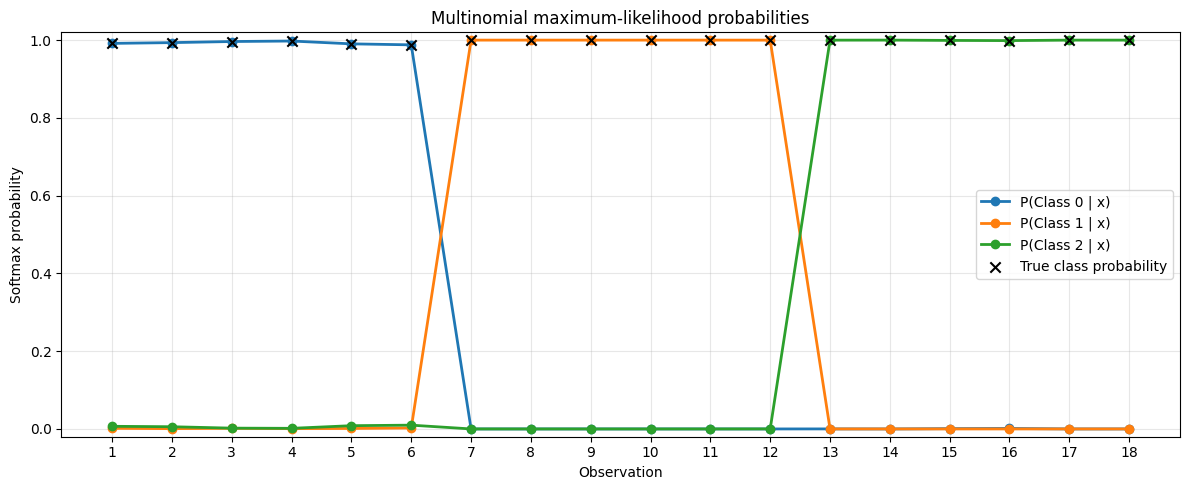

In [13]:
# Plot the multinomial softmax probabilities
probability_matrix = np.array([
    result["probabilities"]
    for result in multinomial_results
])
observation_numbers = np.arange(1, len(probability_matrix) + 1)

plt.figure(figsize=(12, 5))
for class_index in range(n_classes):
    plt.plot(
        observation_numbers,
        probability_matrix[:, class_index],
        marker="o",
        linewidth=2,
        label=f"P(Class {class_index} | x)",
    )

plt.scatter(
    observation_numbers,
    probability_matrix[
        np.arange(len(all_targets)),
        np.asarray(all_targets, dtype=int),
    ],
    color="black",
    marker="x",
    s=55,
    label="True class probability",
    zorder=3,
)
plt.xlabel("Observation")
plt.ylabel("Softmax probability")
plt.title("Multinomial maximum-likelihood probabilities")
plt.ylim(-0.02, 1.02)
plt.xticks(observation_numbers)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
